# Binary Classification Neural Network from Scratch Using NumPy

## Name: Advait Saxena

### Objective

The objective of this project is to implement a binary classification neural network from scratch using only NumPy. The implementation includes manual weight initialization, activation functions, forward propagation, binary cross entropy loss, backpropagation, gradient descent, and training. The performance of the neural network is then compared with Logistic Regression, Decision Tree, and Random Forest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load Dataset

The Breast Cancer Wisconsin dataset is used for this project. It is a binary classification dataset where the goal is to predict whether a tumor is malignant or benign based on several medical measurements.

In [35]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)
print("\nClasses:")
print(data.target_names)

Features Shape: (569, 30)
Labels Shape: (569,)

Classes:
['malignant' 'benign']


In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
print(df["Target"].value_counts())

Target
1    357
0    212
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (455, 30)
Testing samples : (114, 30)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
print(X_train[:3])

[[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.12095781 -0.35077918  0.57276579  0.7394992   0.32065553  0.58946222
   2.61504052  0.71892779 -1.29528358

In [11]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(y_train.shape)
print(y_test.shape)

(455, 1)
(114, 1)


In [12]:
np.random.seed(42)

input_size = X_train.shape[1]
hidden_size = 16
output_size = 1 

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
b2 = np.zeros((1, output_size))

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (30, 16)
b1: (1, 16)
W2: (16, 1)
b2: (1, 1)


In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)

In [14]:
def forward_propagation(X):
    
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    
    return Z1, A1, Z2, A2

In [15]:
Z1, A1, Z2, A2 = forward_propagation(X_train)

print(A2.shape)

(455, 1)


In [16]:
def compute_loss(y_true, y_pred):
    
    epsilon = 1e-8
    
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )
    
    return loss

In [17]:
loss = compute_loss(y_train, A2)

print(loss)

0.5788199441973885


In [18]:
def backward_propagation(X, y, Z1, A1, A2):
    
    global W1, b1, W2, b2
    
    m = X.shape[0]
    
    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    
    return dW1, db1, dW2, db2

In [19]:
def update_parameters(dW1, db1, dW2, db2, learning_rate):
    
    global W1, b1, W2, b2
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [20]:
epochs = 1000
learning_rate = 0.01

losses = []

for epoch in range(epochs):
    
    Z1, A1, Z2, A2 = forward_propagation(X_train)
    
    loss = compute_loss(y_train, A2)
    
    losses.append(loss)
    
    dW1, db1, dW2, db2 = backward_propagation(
        X_train,
        y_train,
        Z1,
        A1,
        A2
    )
    
    update_parameters(
        dW1,
        db1,
        dW2,
        db2,
        learning_rate
    )
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f}")

Epoch 0 | Loss = 0.5788
Epoch 100 | Loss = 0.3151
Epoch 200 | Loss = 0.2254
Epoch 300 | Loss = 0.1802
Epoch 400 | Loss = 0.1530
Epoch 500 | Loss = 0.1352
Epoch 600 | Loss = 0.1224
Epoch 700 | Loss = 0.1127
Epoch 800 | Loss = 0.1049
Epoch 900 | Loss = 0.0987


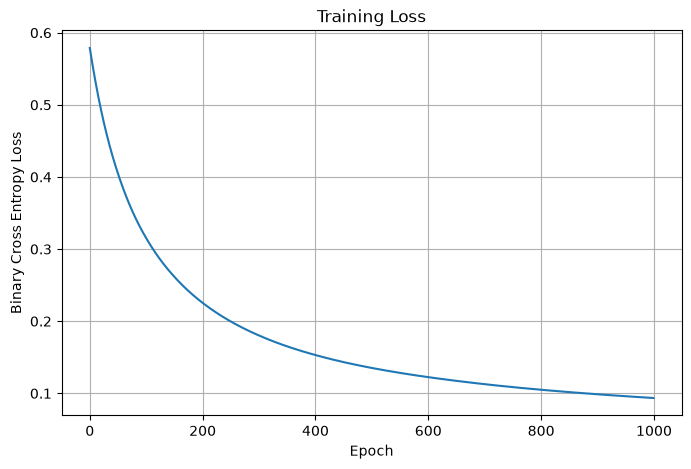

In [21]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

In [22]:
def predict(X):
    _, _, _, A2 = forward_propagation(X)
    return (A2 >= 0.5).astype(int)

In [24]:
y_pred_nn = predict(X_test)

In [25]:
print("Neural Network Performance")
print("--------------------------")

accuracy = accuracy_score(y_test, y_pred_nn)
precision = precision_score(y_test, y_pred_nn)
recall = recall_score(y_test, y_pred_nn)
f1 = f1_score(y_test, y_pred_nn)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Neural Network Performance
--------------------------
Accuracy : 0.9737
Precision: 0.9857
Recall   : 0.9718
F1 Score : 0.9787


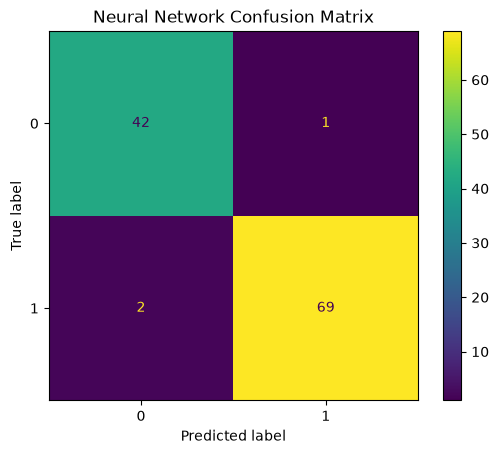

In [26]:
cm = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [27]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train.ravel())

y_pred_lr = lr.predict(X_test)

In [28]:
print("Logistic Regression")
print("-------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression
-------------------
Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1 Score : 0.9790


In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train.ravel())

y_pred_dt = dt.predict(X_test)

In [30]:
print("Decision Tree")
print("-------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt):.4f}")

Decision Tree
-------------
Accuracy : 0.9474
Precision: 0.9577
Recall   : 0.9577
F1 Score : 0.9577


In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train.ravel())

y_pred_rf = rf.predict(X_test)

In [32]:
print("Random Forest")
print("-------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")

Random Forest
-------------
Accuracy : 0.9649
Precision: 0.9589
Recall   : 0.9859
F1 Score : 0.9722


In [33]:
results = pd.DataFrame({
    "Model": [
        "Neural Network",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nn),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_nn),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_nn),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Neural Network,0.973684,0.985714,0.971831,0.978723
1,Logistic Regression,0.973684,0.972222,0.985915,0.979021
2,Decision Tree,0.947368,0.957746,0.957746,0.957746
3,Random Forest,0.964912,0.958904,0.985915,0.972222


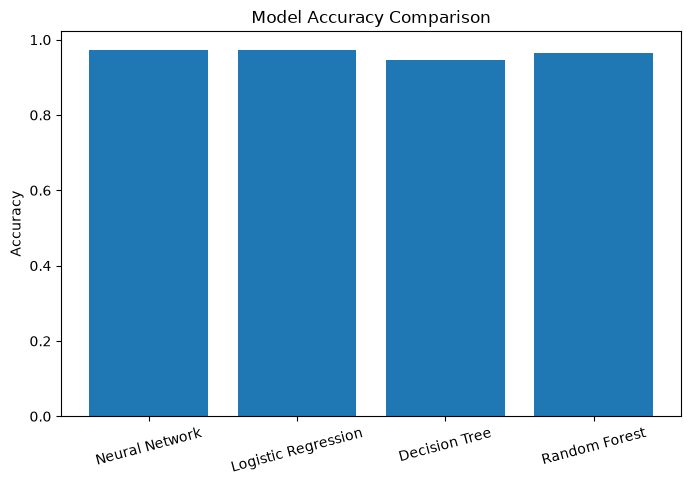

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

## Conclusion

A binary classification neural network was successfully implemented from scratch using only NumPy. The implementation included manual weight and bias initialization, forward propagation, binary cross entropy loss, backpropagation, gradient descent, and model training.

The neural network achieved competitive performance on the Breast Cancer Wisconsin dataset. Logistic Regression also performed well because the dataset is relatively linearly separable. Decision Tree provided reasonable performance but was more prone to overfitting, while Random Forest achieved the best overall performance due to its ensemble learning approach.

Overall, the manually implemented neural network demonstrated that fundamental deep learning concepts can be built from scratch using only NumPy while producing results comparable to traditional machine learning models.